In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

## Load in the data
expr_df = pd.read_csv("../data/raw/TCGA-PANCAN-HiSeq-801x20531/data.csv")

labels_df = pd.read_csv("../data/raw/TCGA-PANCAN-HiSeq-801x20531/labels.csv")

Now that data is loaded, let's take a look around.

In [14]:
display(expr_df.head())
display(labels_df.head())

print(f"Expression matrix shape: {expr_df.shape}")
print(f"Label matrix shape:      {labels_df.shape}")

,Unnamed: 0,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
0,sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
1,sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
2,sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0
3,sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0
4,sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0


,Unnamed: 0,Class
0,sample_0,PRAD
1,sample_1,LUAD
2,sample_2,PRAD
3,sample_3,PRAD
4,sample_4,BRCA


Expression matrix shape: (801, 20532)
Label matrix shape:      (801, 2)


In [15]:
## Are all samples ids equal?
print(expr_df["Unnamed: 0"].equals(labels_df["Unnamed: 0"]))
## True

## Set index

expr_df = expr_df.set_index("Unnamed: 0")
labels_df = labels_df.set_index("Unnamed: 0")

True


False
Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


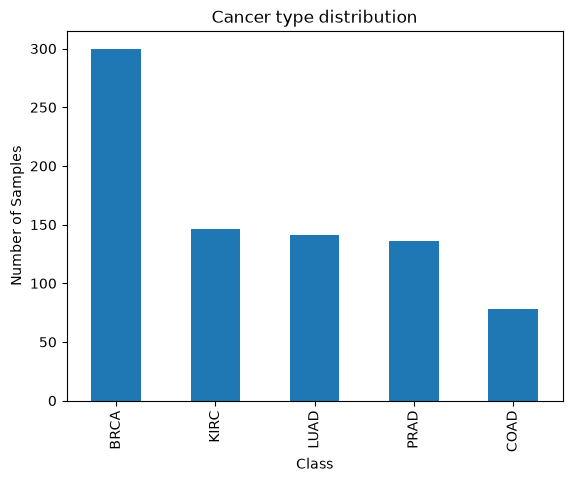

In [16]:
## Counts of different cell types
print(labels_df['Class'].isna().any()) # No missing values, very good

print(labels_df['Class'].value_counts()) # How many samples for each cancer type

labels_df['Class'].value_counts().plot.bar()
plt.ylabel('Number of Samples')
plt.title('Cancer type distribution')
plt.show()
 
## BRCA is most common with 300, but smallest category, COAD,  still has 78.

In [17]:
display(expr_df.head())
expr_df.isna().sum().sum()
## No missing values, excellent
expr_df.index.duplicated().sum()
## No duplicated indices, good
expr_df.iloc[:, :10].describe()

## Looks like some columns have zero variance

zero_var_cols = expr_df.columns[expr_df.nunique() == 1].tolist()
print(len(zero_var_cols)) #267 genes have zero variance

## Drop those columns from your DataFrame
expr_filtered_df = expr_df.drop(columns=zero_var_cols)
expr_filtered_df.shape

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0
sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0
sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,0.0,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0


267


(801, 20264)

In [18]:
## keeping with sci-kit tradition

## I used the zero variance filtered expr above

X_df = expr_filtered_df
y_df = labels_df

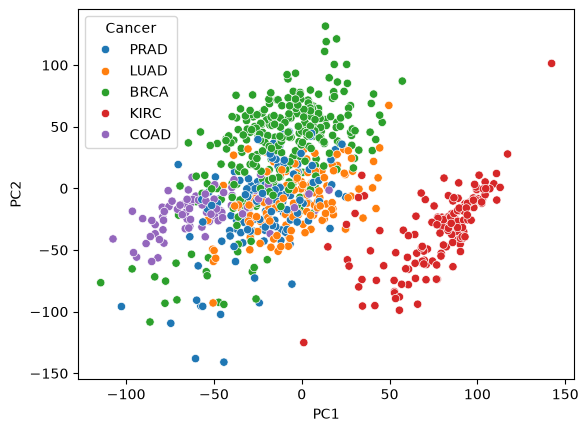

In [19]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns

## Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)

## PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

## Data for plotting

pca_df = pd.DataFrame({"PC1": X_pca[:, 0], "PC2": X_pca[:, 1], "Cancer": y_df['Class']})
pca_df

sns.scatterplot(x="PC1", y="PC2", hue="Cancer", data=pca_df)
plt.show()

In [2]:
import sys

print(sys.executable)

/Users/shanewarland/miniforge3/envs/cancer-ml/bin/python
